# Model simple linear regresi
Info: Datanya dari House Price Advanced regressions techniques

## Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

## Import Dataset

In [15]:
df = pd.read_csv(r"C:\Belajar Pemrograman\Artificial Intelligence\Datasets\Regression\train.csv")

## Menyiapkan Data agar bisa terbaca di Simple Linear Regresi
info: simple linear regresi membutuhkan data dengan 2 dimensi sehingga perlu di reshape

In [16]:
X = np.array(df['OverallQual'])
y = np.array(df['SalePrice'])
#X.shape
print(f'X: {X}')
print(f'y: {y}')

X: [7 6 7 ... 7 5 5]
y: [208500 181500 223500 ... 266500 142125 147500]


In [17]:
# Melakukan reshape
X = X.reshape(-1, 1)
X.shape
X

array([[7],
       [6],
       [7],
       ...,
       [7],
       [5],
       [5]], shape=(1460, 1))

In [18]:
# Sekedar Info untuk mengembalikan yang sudah di reshape bisa di flatten
print(f'X:\n{X}\n')
print(f'X flatten: {X.flatten()}\n')
print(f'y: {y}')

X:
[[7]
 [6]
 [7]
 ...
 [7]
 [5]
 [5]]

X flatten: [7 6 7 ... 7 5 5]

y: [208500 181500 223500 ... 266500 142125 147500]


## Penghitungan 'Proses di balik layar'

In [19]:
variance_x = np.var(X.flatten(), ddof=1)
covariance_xy = np.cov(X.flatten(), y)[0][1]
slope = covariance_xy / variance_x
intercept = np.mean(y) - slope * np.mean(X)

print(f'variance: {variance_x}')
print(f'intercept: {intercept}')
print(f'slope: {slope}')
print(f'covariance: {covariance_xy}')
np.cov(X.flatten(), y)

variance: 1.9126794482991725
intercept: -96206.07951476044
slope: 45435.802593099404
covariance: 86904.12583679947


array([[1.91267945e+00, 8.69041258e+04],
       [8.69041258e+04, 6.31111126e+09]])

## Melakukan Split data

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=2)

## Melatih Model

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model menebak kemudian hasilnya disimpan

In [22]:
y_pred = model.predict(X_test)

## Visualisasi Simple Linear Regression

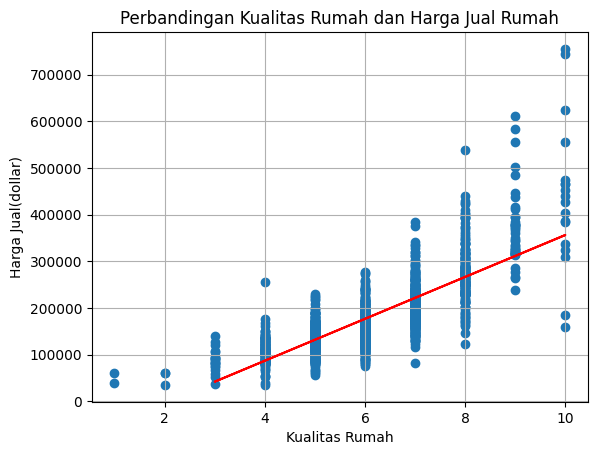

In [23]:
plt.scatter(X, y)
plt.plot(X_test, y_pred, '-r')

plt.title('Perbandingan Kualitas Rumah dan Harga Jual Rumah')
plt.xlabel('Kualitas Rumah')
plt.ylabel('Harga Jual(dollar)')
#plt.xlim(0, 25) Yang ini ga usah
#plt.ylim(0, 25) Yang ini juga ga usah
plt.grid(True)
plt.show()

info: Jauh banget melesetnya

## Melihat tingkat error/kesalahan yang terjadi

In [52]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'MAE: {mae}')
print(f'MSE: {mse}')

MAE: 33728.375587482165
MSE: 2228193882.970913


## what's next
1. Tambahkan Metrik Evaluasi R-squared (R2 Score)
MAE dan MSE kan ngasih tau seberapa meleset angkanya (dalam dolar). Nah, R-squared ini fungsinya beda, dia ngasih nilai persentase (dari 0 sampai 1). Tujuannya buat ngasih tau: "Berapa persen sih variasi harga rumah itu bisa dijelaskan murni cuma dari kualitas rumahnya aja?" Metrik ini gampang banget dipahami buat ditarik kesimpulan.

2. Bikin Visualisasi Residual Plot (Plot Error)
Proses regresi itu belum lengkap kalau belum ngecek residual (selisih antara harga asli dan tebakan). Biasanya data science pro bakal bikin scatter plot khusus buat ngelihat apakah error-nya ini ngacak atau malah ngebentuk pola tertentu. Kalau ngebentuk pola, berarti ada yang salah sama pilihan modelnya.

3. Rapikan Format Angka di Visualisasi
Di plot kamu sekarang, angka di sumbu Y (Harga Jual) kan nolnya banyak banget tuh (100000, 200000). Ini bisa di-upgrade biar nampilin format yang lebih gampang dibaca orang awam, misalnya diubah jadi "100k", "200k", atau "300k".

1. Arti dari R^2 score?

Artinya, 66.35% dari naik-turunnya harga rumah (SalePrice) di dataset ini bisa ditebak murni cuma dari skor kualitas rumahny(OverallQual) aja.
Sisa 33.65%-nya lagi dipengaruhi sama faktor-faktor lain yang nggak kita masukin ke model sekarang (kayak luas tanah, lokasi, ada kolam renang atau nggak, dsb).

In [25]:
y_pred = model.predict(X_test)
r_squared = r2_score(y_test, y_pred)

print(f'R-squared: {r_squared}')

R-squared: 0.6635299601818623


2. Visualisasi residual plot: pola corong ini ngasih tahu kita insight penting: model regresi kamu lumayan akurat buat nebak harga rumah-rumah murah/standar, tapi makin kesulitan dan sering meleset jauh kalau disuruh nebak rumah-rumah mewah.

Ini masuk akal banget di dunia nyata. Rumah mewah harganya lebih bervariasi karena dipengaruhi gengsi, luas kolam renang, garasi raksasa, atau lokasi elit, di mana data-data itu nggak ada di model kita sekarang (karena kita cuma pakai skor kualitas biasa).

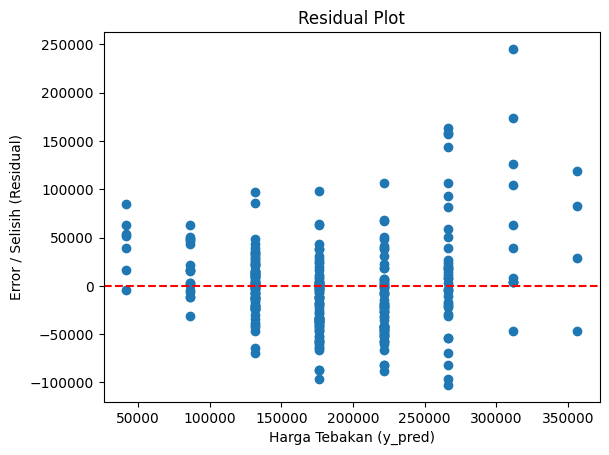

In [30]:
residual = y_test - y_pred
residual


plt.scatter(y_pred, residual)
plt.axhline(y=0, color='r', linestyle='--') # ini buat bikin garis merah putus-putus di titik 0
plt.title('Residual Plot')
plt.xlabel('Harga Tebakan (y_pred)')
plt.ylabel('Error / Selisih (Residual)')
plt.show()

supaya lebih jelas corongnya:

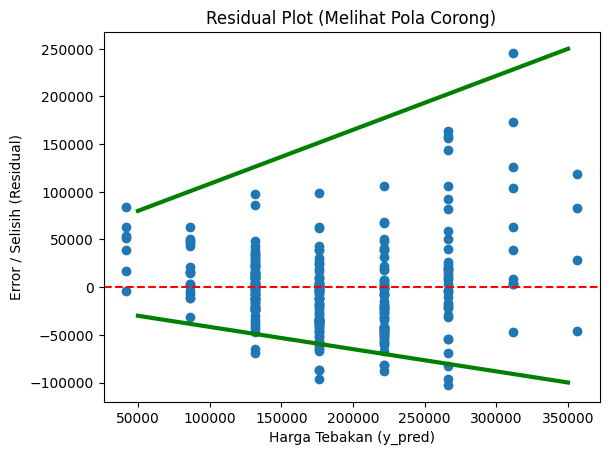

In [31]:
plt.scatter(y_pred, residual)
plt.axhline(y=0, color='r', linestyle='--') 

# --- TAMBAHAN UNTUK MENGGAMBAR BENTUK CORONG ---
# Bikin garis corong batas atas
plt.plot([50000, 350000], [80000, 250000], color='green', linewidth=3)
# Bikin garis corong batas bawah
plt.plot([50000, 350000], [-30000, -100000], color='green', linewidth=3)

plt.title('Residual Plot (Melihat Pola Corong)')
plt.xlabel('Harga Tebakan (y_pred)')
plt.ylabel('Error / Selisih (Residual)')
plt.show()

In [32]:
from matplotlib.ticker import FuncFormatter

def format_k(angka, posisi):
    return f'{int(angka/1000)}K'

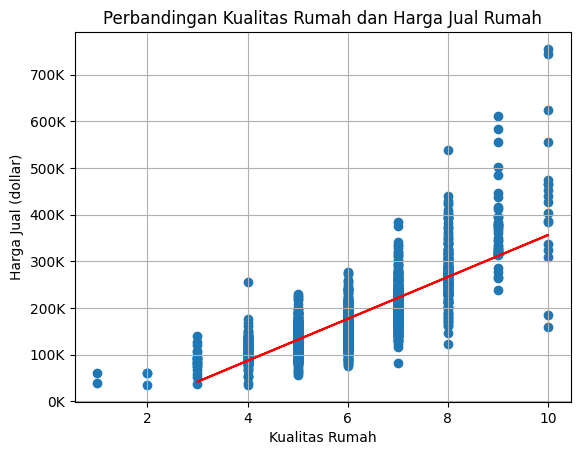

In [35]:
plt.scatter(X, y)
plt.plot(X_test, y_pred, '-r')

plt.title('Perbandingan Kualitas Rumah dan Harga Jual Rumah')
plt.xlabel('Kualitas Rumah')
plt.ylabel('Harga Jual (dollar)')

# --- TAMBAHAN UNTUK FORMAT ANGKA K ---
formatter = FuncFormatter(format_k)
plt.gca().yaxis.set_major_formatter(formatter)
# -------------------------------------

plt.grid(True)
plt.show()